# Karatsuba Multiplication

### 1. Introduction 

The Karatsuba algorithm is a fast multiplication algorithm for integers. It is a **divide-and-conquer algorithm** that reduces the multiplication of two n-digit numbers to three multiplications of n/2-digit numbers and, by repeating this reduction, to at most $n^{log_2{3}} \approx n^{1.58}$ single-digit multiplications.

### 2. Algorithm

The basic principle of Karatsuba's algorithm is divide-and-conquer, using a formula that allows one to compute the product of two large numbers $x$ and $y$ using three multiplications of smaller numbers, each with about half as many digits as $x$ or $y$, plus some additions and digit shifts. This basic step is, in fact, a generalization of a similar complex multiplication algorithm, where the imaginary unit $i$ is replaced by a power of the base.

Let $x$ and $y$ be represented as $n$-digit strings in some base $B$. For any positive integer $m$ less than $n$, one can write the two given numbers as
\begin{align*}
    x &= x_1 B^m + x_0, \\
    y &= y_1 B^m + y_0,
\end{align*}
where $x_0$ and $y_0$ are less than $B^m$. The product is then
\begin{align*}
    xy &= (x_1 B^m + x_0)(y_1 B^m + y_0) \\
       &= x_1 y_1 B^{2m} + (x_1 y_0 + x_0 y_1) B^m + x_0 y_0 \\
       &= z_2 B^{2m} + z_1 B^m + z_0,
\end{align*}
where
\begin{align*}
    z_2 &= x_1 y_1, \\
    z_1 &= x_1 y_0 + x_0 y_1, \\
    z_0 &= x_0 y_0.
\end{align*}



Here is a flowchart illustrating the Karatsuba algorithm:

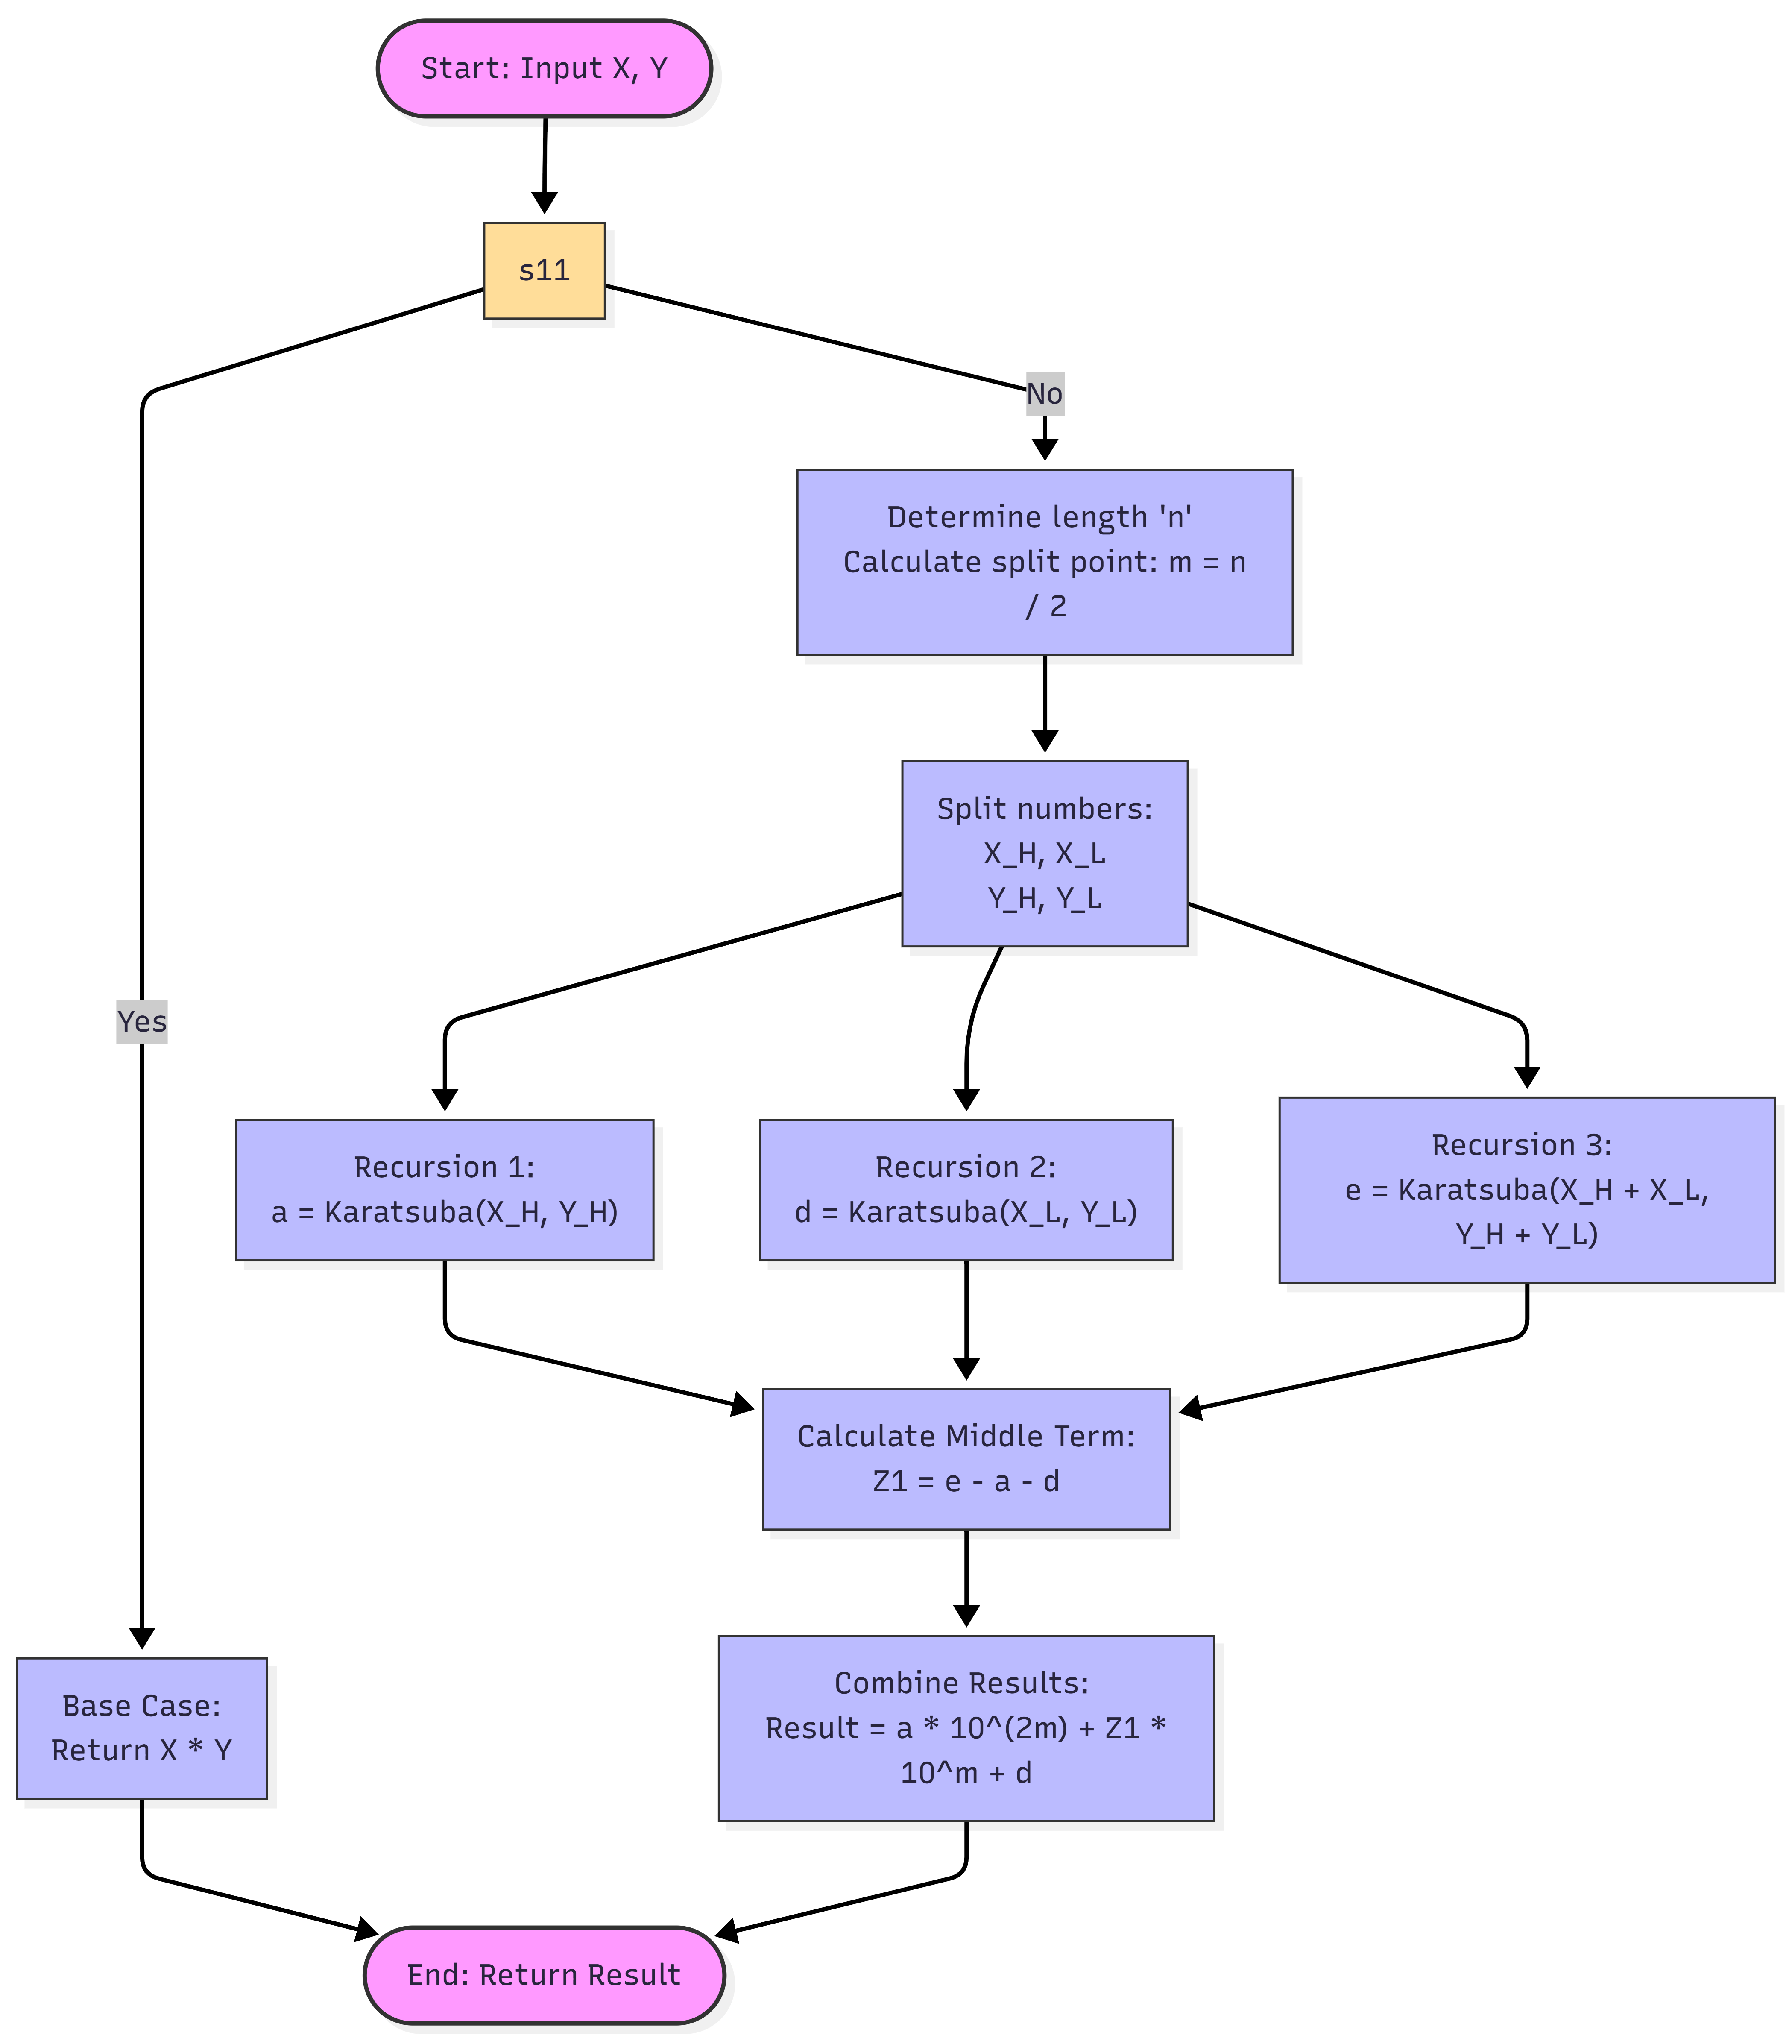

In [26]:
from IPython.display import Image
Image("Karatsuba_Multiplication_flowchart.png", width=600)

Here is a Python implementation of the Karatsuba algorithm for base-10 numbers:

In [19]:
from math import ceil, floor
#math.ceil(x) Return the ceiling of x as a float, the smallest integer value greater than or equal to x.
#math.floor(x) Return the floor of x as a float, the largest integer value less than or equal to x.

def karatsuba(x,y):
    #base case
    if x < 10 and y < 10: # in other words, if x and y are single digits
        return x*y

    n = max(len(str(x)), len(str(y)))
    m = (n + 1) // 2 

    x_H = x // (10**m)
    x_L = x % (10**m)

    y_H = y // (10**m)
    y_L = y % (10**m)
    
    #recursive steps
    a = karatsuba(x_H,y_H)
    d = karatsuba(x_L,y_L)
    e = karatsuba(x_H + x_L, y_H + y_L) - a - d

    return int(a*(10**(m*2)) + e*(10**m) + d)

To compare speed of this implemementation here is Naive Multiplication Algorithm:

In [20]:
def naive_multiplication(x, y):

    if x == 0 or y == 0:
        return 0

    str_x = str(x)
    str_y = str(y)
    
    result = [0] * (len(str_x) + len(str_y))

    str_x = str_x[::-1]
    str_y = str_y[::-1]
    
    for i in range(len(str_x)):
        for j in range(len(str_y)):
            
            product = int(str_x[i]) * int(str_y[j])
            
            result[i + j] += product
            
            result[i + j + 1] += result[i + j] // 10  
            result[i + j] %= 10 

    while len(result) > 1 and result[-1] == 0:
        result.pop()

    final_result_str = ''.join(map(str, result[::-1]))
    return int(final_result_str)

Here is speed comparison of those algorithms:

In [22]:
import time
from math import ceil, floor

def compare_algorithms(x, y):

    str_x = str(x) if len(str(x)) < 15 else str(x)[:8] + "..." + str(x)[-5:]
    str_y = str(y) if len(str(y)) < 15 else str(y)[:8] + "..." + str(y)[-5:]
    print(f"Multiplication: {str_x} * {str_y}")
    
    start_k = time.perf_counter()
    result_k = karatsuba(x, y)
    end_k = time.perf_counter()
    time_k = end_k - start_k

    start_n = time.perf_counter()
    result_n = naive_multiplication(x, y)
    end_n = time.perf_counter()
    time_n = end_n - start_n
    
    print(f"  Is the result correct? : {'✅ Yes' if result_k == result_n else '❌ No'}")
    print(f"  Time Karatsuba: {time_k:.8f} seconds")
    print(f"  Time Naive   : {time_n:.8f} seconds")
    
    if time_k < time_n:
        print(f"  => Karatsuba is {(time_n - time_k):.8f} s faster")
    else:
        print(f"  => Naive is {(time_k - time_n):.8f} s faster")
    print("-" * 50)


compare_algorithms(12, 12)
compare_algorithms(1234, 4321)

duze_x = 3141592653589793238462643383279502884197169399375105820974944592
duze_y = 2718281828459045235360287471352662497757247093699959574966967627
compare_algorithms(duze_x, duze_y)

Multiplication: 12 * 12
  Is the result correct? : ✅ Yes
  Time Karatsuba: 0.00001970 seconds
  Time Naive   : 0.00003700 seconds
  => Karatsuba is 0.00001730 s faster
--------------------------------------------------
Multiplication: 1234 * 4321
  Is the result correct? : ✅ Yes
  Time Karatsuba: 0.00002010 seconds
  Time Naive   : 0.00003050 seconds
  => Karatsuba is 0.00001040 s faster
--------------------------------------------------
Multiplication: 31415926...44592 * 27182818...67627
  Is the result correct? : ✅ Yes
  Time Karatsuba: 0.00240280 seconds
  Time Naive   : 0.00331480 seconds
  => Karatsuba is 0.00091200 s faster
--------------------------------------------------


As we can see **Karatsuba algorithm is faster**, in particular when numbers are bigger.

Source: https://en.wikipedia.org/wiki/Karatsuba_algorithm \
Source: https://brilliant.org/wiki/karatsuba-algorithm/

### 3. Behavioral implementation